# Plant Disease Recognition Using Deep Learning

This notebook implements a deep learning-based plant disease recognition system using Convolutional Neural Networks (CNNs) and transfer learning with MobileNetV2.

The workflow includes dataset preparation, data augmentation, model training, evaluation, performance visualization, and single-image disease prediction.

In [1]:
# DirectML Setup is already installed in .venv310
# If reinstalling: %pip install tensorflow-cpu==2.10.0 tensorflow-directml-plugin 'protobuf<3.20,>=3.19.6' 'numpy<2.0.0' 'keras<2.11,>=2.10.0'

## 1. Environment Setup and GPU Configuration

This section configures the TensorFlow environment and verifies the availability of the NVIDIA GPU for accelerated deep learning computation.

In [2]:
import os
import warnings

# Select NVIDIA RTX 3050 through DirectML BEFORE importing TensorFlow
os.environ["DML_VISIBLE_DEVICES"] = "0"

# Suppress verbose TensorFlow messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import tensorflow as tf

tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

# List available DirectML GPU devices
devices = tf.config.list_physical_devices()
print("Available Devices:", devices)

gpus = tf.config.list_physical_devices('GPU')
print(f"\nDetected {len(gpus)} GPU(s) with DirectML:")
for gpu in gpus:
    print(" -", gpu)

Available Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Detected 1 GPU(s) with DirectML:
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 2. Dataset Organization and Class Information

This section loads the plant disease dataset and identifies the different disease classes available for classification.

In [3]:
import os

BASE_DIR = "./dataset"

if not os.path.exists(BASE_DIR):
    raise FileNotFoundError(f"Directory '{BASE_DIR}' not found. Please ensure class folders are in './dataset'.")

plant_classes = sorted([
    d for d in os.listdir(BASE_DIR) 
    if os.path.isdir(os.path.join(BASE_DIR, d)) and not d.startswith('.')
])

print(f"Successfully located BASE_DIR: {BASE_DIR}")
print(f"Number of plant classes found: {len(plant_classes)}")
print("Sample classes:", plant_classes[:5])

Successfully located BASE_DIR: ./dataset
Number of plant classes found: 41
Sample classes: ['Ashok.H', 'Ashok.U', 'Bamboo.U', 'Barlaria.H', 'Bel.H']


## 3. Data Preprocessing and Augmentation

The dataset is prepared for model training by resizing images, creating training and validation datasets, and applying data augmentation to improve model generalization.

In [4]:
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (224, 224)
BATCH_SIZE = 4

# 1. Load Training Dataset (80% of data)
train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# 2. Load Validation Dataset (20% of data)
val_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# 3. Create a small separate Test set from the Validation set
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 5)
val_ds = val_ds.skip(val_batches // 5)

NUM_CLASSES = len(train_ds.class_names)
print(f"\nSuccessfully loaded {NUM_CLASSES} classes into memory!")

# 4. Define Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2)
], name="data_augmentation")

# 5. Apply Augmentation on Dataset
# Conservative settings for DirectML stability
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=1
)

# 6. Conservative prefetching
train_ds = train_ds.prefetch(buffer_size=1)
val_ds = val_ds.prefetch(buffer_size=1)
test_ds = test_ds.prefetch(buffer_size=1)

Found 8581 files belonging to 41 classes.
Using 6865 files for training.
Found 8581 files belonging to 41 classes.
Using 1716 files for validation.

Successfully loaded 41 classes into memory!


## 4. CNN Model Architecture

A Convolutional Neural Network (CNN) is constructed for plant disease classification.

The architecture consists of convolutional layers for feature extraction, pooling layers for dimensionality reduction, and fully connected layers for final classification.

In [5]:
import os
import re
import warnings
import tensorflow as tf
from tensorflow.keras import layers, models
from IPython.display import HTML, display

# Suppress AutoGraph while_loop tracing logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

def build_cnn_model(num_classes):
    model = models.Sequential([
        # Specify the input shape (224x224 RGB images)
        layers.Input(shape=(224, 224, 3)),

        # 1. Rescale pixel values from [0, 255] to [0.0, 1.0]
        layers.Rescaling(1./255),

        # 2. Convolutional Block 1
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # 3. Convolutional Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # 4. Convolutional Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # 5. Classification Head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Drops 50% of connections randomly to prevent overfitting
        layers.Dense(num_classes, activation='softmax') # Outputs probabilities for each class
    ])
    return model

# Instantiate the model
cnn_model = build_cnn_model(num_classes=NUM_CLASSES)

# Function to render the exact Rich-styled colored summary table
def display_rich_summary(model):
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])

    def format_size(params):
        bytes_size = params * 4
        if bytes_size >= 1024 * 1024:
            return f"{bytes_size / (1024 * 1024):.2f} MB"
        elif bytes_size >= 1024:
            return f"{bytes_size / 1024:.2f} KB"
        else:
            return f"{bytes_size} B"

    def color_shape(shape_tuple):
        shape_str = str(shape_tuple)
        shape_str = shape_str.replace("None", "<span style='color: #00d7ff;'>None</span>")
        shape_str = re.sub(r'\b(\d+)\b', r"<span style='color: #00af00;'>\1</span>", shape_str)
        return shape_str

    rows_html = ""
    for layer in model.layers:
        name = layer.name
        class_name = layer.__class__.__name__
        layer_col = f"{name} <span style='color: #0087ff;'>({class_name})</span>"
        shape_col = color_shape(layer.output_shape)
        p_count = layer.count_params()
        param_col = f"<span style='color: #00af00;'>{p_count:,}</span>"

        rows_html += f"""
        <tr style="border-bottom: 1px solid #0087ff;">
            <td style="padding: 6px 14px; text-align: left; font-family: monospace; border-right: 1px solid #0087ff;">{layer_col}</td>
            <td style="padding: 6px 14px; text-align: left; font-family: monospace; border-right: 1px solid #0087ff;">{shape_col}</td>
            <td style="padding: 6px 14px; text-align: right; font-family: monospace;">{param_col}</td>
        </tr>
        """

    html = f"""
    <div style="font-family: Menlo, 'DejaVu Sans Mono', Consolas, 'Courier New', monospace; font-size: 13px; line-height: 1.5; color: #f0f0f0; margin: 10px 0;">
        <div style="font-weight: bold; margin-bottom: 8px;">Model: &quot;{model.name}&quot;</div>
        <table style="border: 1px solid #0087ff; border-collapse: collapse; background: transparent; width: 100%; max-width: 650px;">
            <thead>
                <tr style="border-bottom: 2px solid #0087ff; font-weight: bold;">
                    <th style="padding: 8px 14px; text-align: left; border-right: 1px solid #0087ff;">Layer (type)</th>
                    <th style="padding: 8px 14px; text-align: left; border-right: 1px solid #0087ff;">Output Shape</th>
                    <th style="padding: 8px 14px; text-align: right;">Param #</th>
                </tr>
            </thead>
            <tbody>
                {rows_html}
            </tbody>
        </table>
        <div style="margin-top: 10px; font-weight: bold;">
            Total params: <span style="color: #00af00;">{total_params:,} ({format_size(total_params)})</span><br>
            Trainable params: <span style="color: #00af00;">{trainable_params:,} ({format_size(trainable_params)})</span><br>
            Non-trainable params: <span style="color: #00af00;">{non_trainable_params:,} ({format_size(non_trainable_params)})</span>
        </div>
    </div>
    """
    display(HTML(html))

# Render the colored visual table
display_rich_summary(cnn_model)

Layer (type),Output Shape,Param #
rescaling (Rescaling),"(None, 224, 224, 3)",0
conv2d (Conv2D),"(None, 222, 222, 32)",896
max_pooling2d (MaxPooling2D),"(None, 111, 111, 32)",0
conv2d_1 (Conv2D),"(None, 109, 109, 64)","18,496"
max_pooling2d_1 (MaxPooling2D),"(None, 54, 54, 64)",0
conv2d_2 (Conv2D),"(None, 52, 52, 128)","73,856"
max_pooling2d_2 (MaxPooling2D),"(None, 26, 26, 128)",0
flatten (Flatten),"(None, 86528)",0
dense (Dense),"(None, 128)","11,075,712"
dropout (Dropout),"(None, 128)",0


## 5. CNN Model Compilation

The CNN model is compiled using an appropriate optimizer, loss function, and accuracy metric before training.

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ CNN model compiled successfully!")

✅ CNN model compiled successfully!


## 6. GPU Verification

This section performs a small computation to verify that TensorFlow can successfully utilize the available GPU for accelerated computation.

In [7]:
# Test GPU computation before starting CNN training

with tf.device('/GPU:0'):
    a = tf.random.normal((2000, 2000))
    b = tf.random.normal((2000, 2000))
    c = tf.matmul(a, b)

print("GPU test successful!")
print(c.shape)

GPU test successful!
(2000, 2000)


## 7. Training Stability Test

A short training run is performed to verify that the model, dataset pipeline, and GPU configuration are working correctly before starting the complete training process.

In [8]:
# 1-epoch stability test

test_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1,
    verbose=1
)

1717/1717 [==============================] - 323s 186ms/step - loss: 2.9865 - accuracy: 0.1502 - val_loss: 1.7439 - val_accuracy: 0.4157


## 8. CNN Model Training

The CNN model is trained on the plant disease dataset for multiple epochs.

Validation data is used during training to monitor the model's generalization performance, while callbacks are used to save the best-performing model.

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Set up automated callbacks
callbacks = [
    # Stops training if validation loss doesn't improve for 5 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Automatically saves the best version of your model
    ModelCheckpoint(
        'plant_disease_recog_model_pwp.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# 3. Start Training!
EPOCHS = 15

print("🚀 Starting training on DirectML GPU...")

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

🚀 Starting training on DirectML GPU...
Epoch 1/15
1716/1717 [============================>.] - ETA: 0s - loss: 2.0733 - accuracy: 0.3160
Epoch 1: val_accuracy improved from -inf to 0.60247, saving model to plant_disease_recog_model_pwp.keras
1717/1717 [==============================] - 307s 178ms/step - loss: 2.0732 - accuracy: 0.3161 - val_loss: 1.1770 - val_accuracy: 0.6025
Epoch 2/15
1716/1717 [============================>.] - ETA: 0s - loss: 1.7509 - accuracy: 0.4159
Epoch 2: val_accuracy improved from 0.60247 to 0.69840, saving model to plant_disease_recog_model_pwp.keras
1717/1717 [==============================] - 326s 189ms/step - loss: 1.7509 - accuracy: 0.4159 - val_loss: 0.9477 - val_accuracy: 0.6984
Epoch 3/15
1716/1717 [============================>.] - ETA: 0s - loss: 1.5503 - accuracy: 0.4830
Epoch 3: val_accuracy improved from 0.69840 to 0.76090, saving model to plant_disease_recog_model_pwp.keras
1717/1717 [==============================] - 344s 199ms/step - loss: 1.5

## 9. CNN Model Evaluation

The trained CNN model is evaluated on the test dataset to determine its final classification loss and accuracy.

In [10]:
# Load the saved best model
model = tf.keras.models.load_model('plant_disease_recog_model_pwp.keras')

# Evaluate the saved best model on unseen test data
test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print(f"\n==========================================")
print(f"🎯 Final Test Accuracy : {test_acc * 100:.2f}%")
print(f"📉 Final Test Loss     : {test_loss:.4f}")
print(f"==========================================")

85/85 [==============================] - 14s 140ms/step - loss: 0.2236 - accuracy: 0.9265

🎯 Final Test Accuracy : 92.65%
📉 Final Test Loss     : 0.2236


## 10. Training Performance Visualization

This section prepares the required visualization tools for analyzing the training and validation performance of the model.

In [11]:
%pip install matplotlib seaborn scikit-learn

## 10.1 Training and Validation Performance Curves

This section visualizes the training and validation performance of the CNN across the training epochs.

The accuracy curve shows how the classification accuracy changes during training, while the loss curve shows the change in the model's prediction error. Comparing training and validation curves helps evaluate model learning, convergence, and generalization.

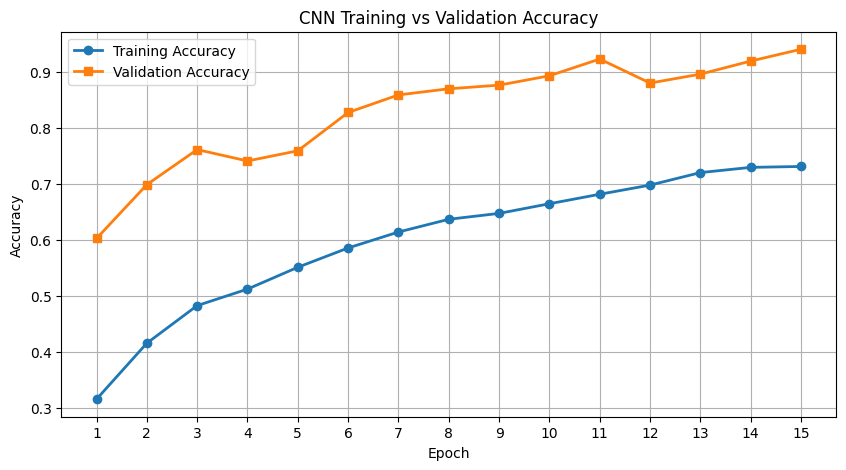

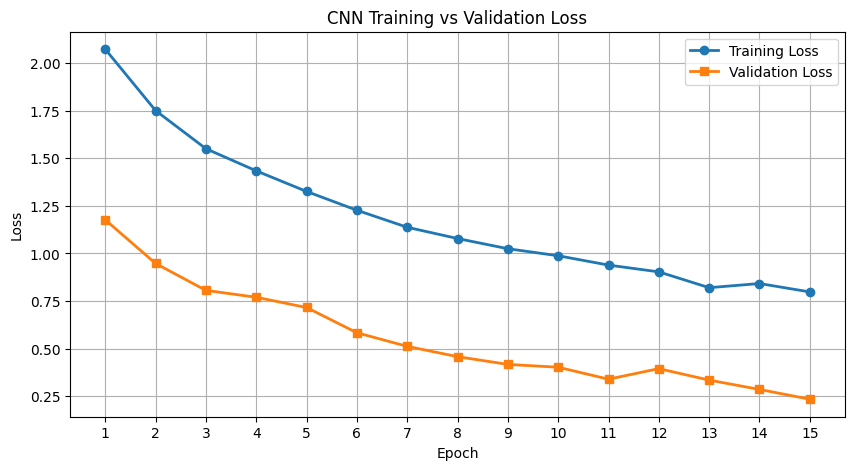

In [14]:
import matplotlib.pyplot as plt

# Recorded CNN training history (15 epochs)
train_accuracy = [0.3161,0.4159,0.4829,0.5123,0.5512,0.5856,0.6140,0.6367,0.6472,0.6644,0.6813,0.6976,0.7199,0.7292,0.7308]
val_accuracy   = [0.6025,0.6984,0.7609,0.7406,0.7587,0.8270,0.8583,0.8692,0.8757,0.8924,0.9222,0.8794,0.8953,0.9186,0.9397]

train_loss = [2.0732,1.7509,1.5506,1.4343,1.3260,1.2273,1.1378,1.0787,1.0251,0.9882,0.9391,0.9035,0.8204,0.8422,0.7981]
val_loss   = [1.1770,0.9477,0.8062,0.7701,0.7163,0.5836,0.5122,0.4580,0.4173,0.4025,0.3397,0.3951,0.3348,0.2858,0.2344]

epochs = range(1,16)

# Accuracy
plt.figure(figsize=(10,5))
plt.plot(epochs, train_accuracy, marker='o', linewidth=2, label='Training Accuracy')
plt.plot(epochs, val_accuracy, marker='s', linewidth=2, label='Validation Accuracy')
plt.title('CNN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(10,5))
plt.plot(epochs, train_loss, marker='o', linewidth=2, label='Training Loss')
plt.plot(epochs, val_loss, marker='s', linewidth=2, label='Validation Loss')
plt.title('CNN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.show()

## 11. Classification Report and Confusion Matrix

The classification performance of the trained model is analyzed using a classification report and confusion matrix.

These metrics provide detailed information about precision, recall, F1-score, and class-wise prediction performance.


--- Detailed Classification Report ---
                          precision    recall  f1-score   support

                 Ashok.H       1.00      1.00      1.00         5
                 Ashok.U       1.00      1.00      1.00         7
                Bamboo.U       1.00      1.00      1.00         3
              Barlaria.H       1.00      1.00      1.00        13
                   Bel.H       1.00      0.88      0.93        16
                   Bel.U       1.00      1.00      1.00        16
Clerodendrum splendens.H       1.00      0.80      0.89        10
Clerodendrum splendens.U       1.00      1.00      1.00         4
                 Curry.U       0.67      1.00      0.80         6
          CustardApple.H       1.00      1.00      1.00        14
          CustardApple.U       0.71      1.00      0.83         5
                 Guava.H       1.00      1.00      1.00         3
                 Guava.U       1.00      1.00      1.00         1
             Harsingar.H       1.00

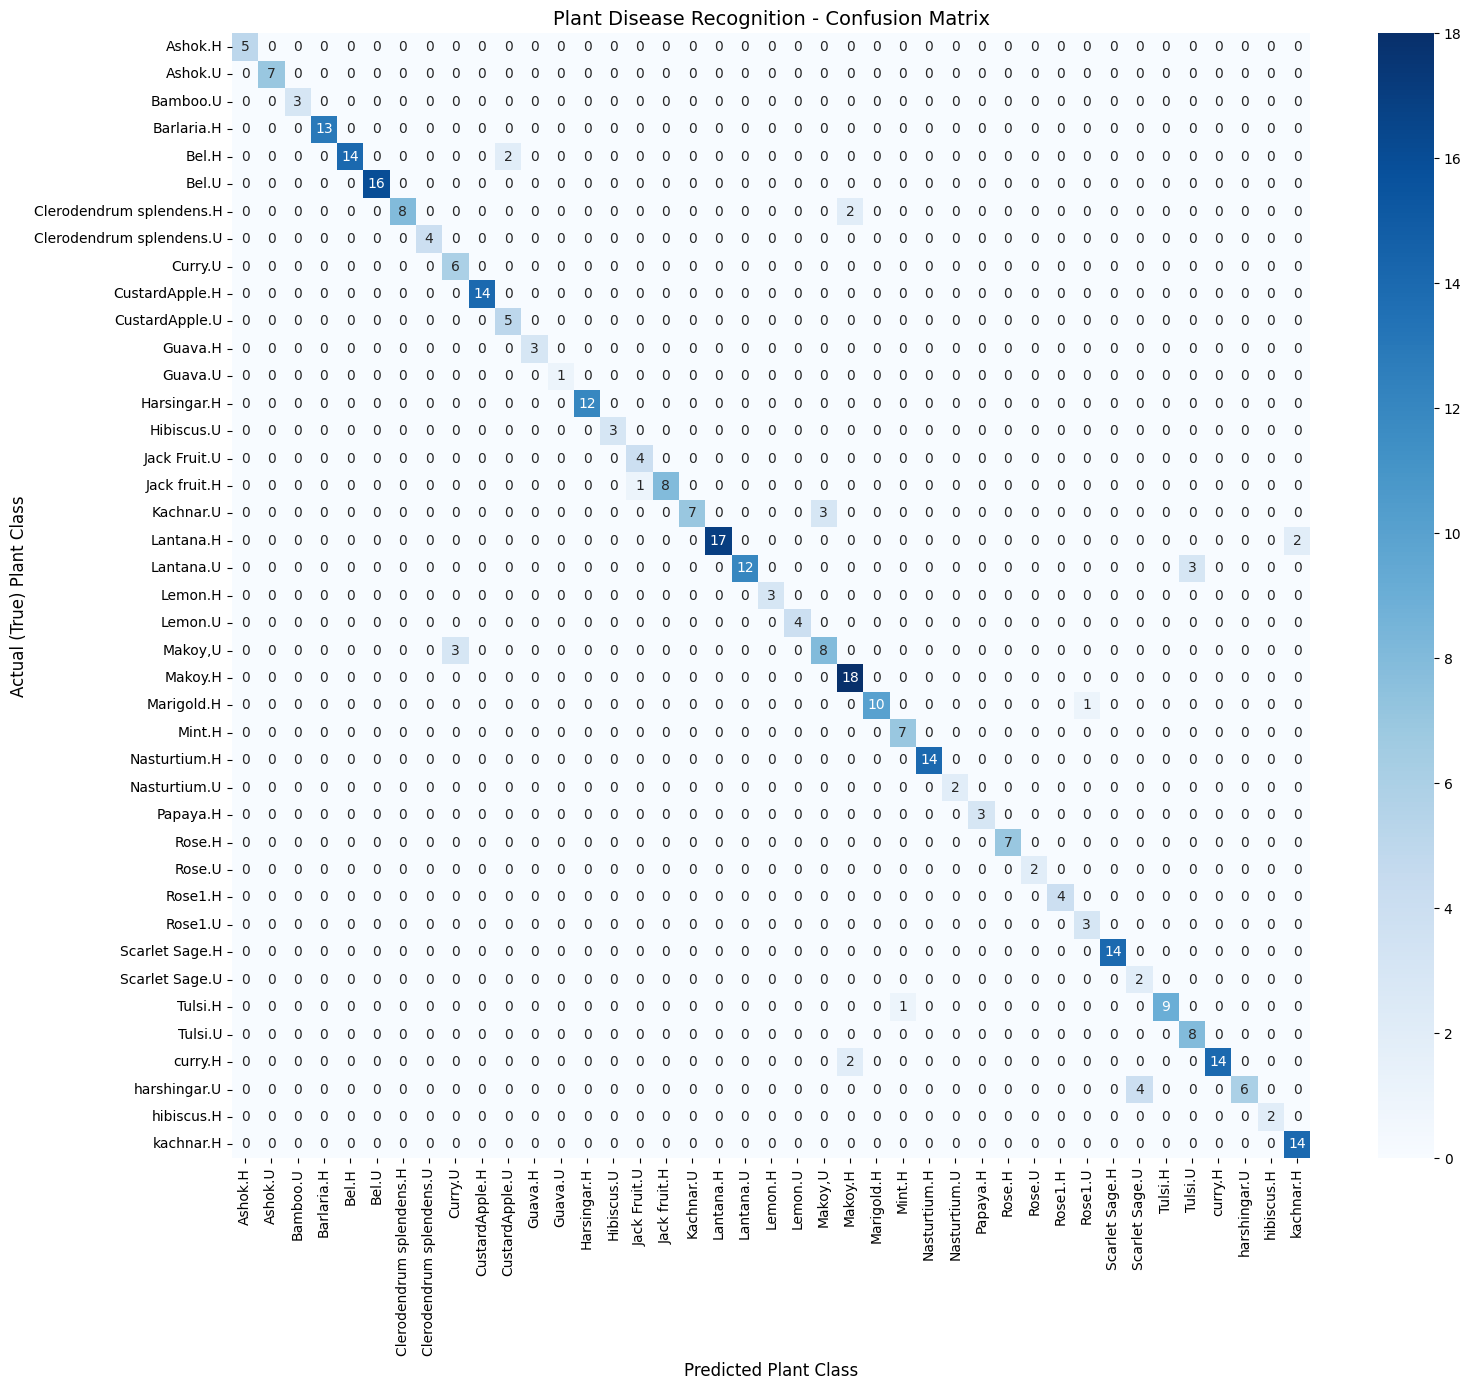

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

# 1. Retrieve class names from the dataset directory
class_names = sorted([
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d))
    and not d.startswith('.')
])

num_classes = len(class_names)
all_labels = np.arange(num_classes)

# 2. Collect true labels and predictions
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

# 3. Print Classification Report
print("\n--- Detailed Classification Report ---")

print(classification_report(
    y_true,
    y_pred,
    labels=all_labels,
    target_names=class_names,
    zero_division=0
))

# 4. Plot Confusion Matrix Heatmap
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=all_labels
)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Plant Class', fontsize=12)
plt.ylabel('Actual (True) Plant Class', fontsize=12)
plt.title(
    'Plant Disease Recognition - Confusion Matrix',
    fontsize=14
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 11.1 ROC Curve and AUC Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the CNN's ability to distinguish between the different plant disease classes.

The Area Under the Curve (AUC) provides a summary of the model's discrimination performance. For this multi-class classification problem, the One-vs-Rest (OvR) strategy is used to calculate the macro-average AUC and generate the ROC curve.

Loading trained CNN model...
✅ CNN model loaded
✅ Number of classes: 41

Loading validation dataset...
Found 8581 files belonging to 41 classes.
Using 1716 files for validation.
✅ Test split recreated

Evaluating test images for ROC-AUC...
✅ Evaluated 340 test images

           ROC-AUC ANALYSIS
Macro-Average AUC    : 0.9995
Weighted-Average AUC : 0.9996
Micro-Average AUC    : 0.9996


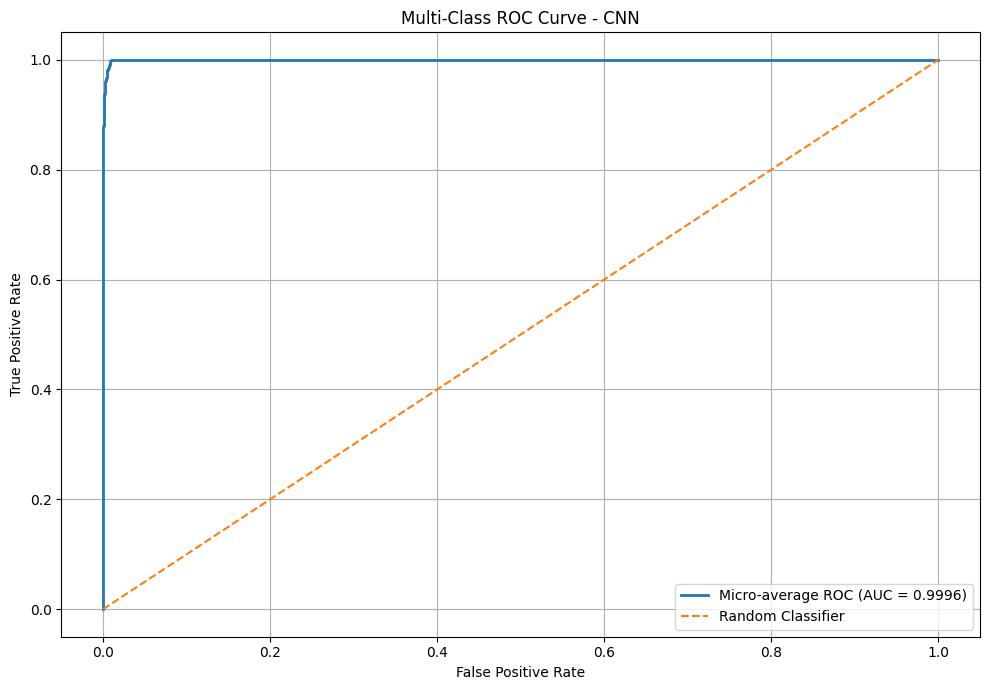

In [5]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score


# ============================================================
# ROC CURVE AND AUC ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. Define Paths and Settings
# ------------------------------------------------------------

BASE_DIR = "./dataset"

MODEL_PATH = "plant_disease_recog_model_pwp.keras"

IMG_SIZE = (224, 224)
BATCH_SIZE = 4
SEED = 123


# ------------------------------------------------------------
# 2. Load the Trained CNN
# ------------------------------------------------------------

print("Loading trained CNN model...")

roc_model = tf.keras.models.load_model(
    MODEL_PATH
)

print("✅ CNN model loaded")


# ------------------------------------------------------------
# 3. Retrieve Class Names
# ------------------------------------------------------------

class_names = sorted([
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d))
    and not d.startswith(".")
])

NUM_CLASSES = len(class_names)

print(f"✅ Number of classes: {NUM_CLASSES}")


# ------------------------------------------------------------
# 4. Recreate the Same Validation Dataset
# ------------------------------------------------------------

print("\nLoading validation dataset...")

val_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)


# ------------------------------------------------------------
# 5. Recreate the Same Test Split Used in the Notebook
# ------------------------------------------------------------

val_batches = tf.data.experimental.cardinality(
    val_ds
)

test_ds = val_ds.take(
    val_batches // 5
)

print("✅ Test split recreated")


# ------------------------------------------------------------
# 6. Collect True Labels and Prediction Probabilities
# ------------------------------------------------------------

y_true = []
y_pred_probs = []

print("\nEvaluating test images for ROC-AUC...")

for images, labels in test_ds:

    predictions = roc_model.predict(
        images,
        verbose=0
    )

    y_pred_probs.extend(
        predictions
    )

    y_true.extend(
        labels.numpy()
    )


y_true = np.array(y_true)

y_pred_probs = np.array(
    y_pred_probs
)

print(
    f"✅ Evaluated {len(y_true)} test images"
)


# ------------------------------------------------------------
# 7. Convert Labels to One-vs-Rest Format
# ------------------------------------------------------------

all_labels = np.arange(
    NUM_CLASSES
)

y_true_binary = label_binarize(
    y_true,
    classes=all_labels
)


# ------------------------------------------------------------
# 8. Calculate AUC Scores
# ------------------------------------------------------------

macro_auc = roc_auc_score(
    y_true_binary,
    y_pred_probs,
    multi_class="ovr",
    average="macro"
)

weighted_auc = roc_auc_score(
    y_true_binary,
    y_pred_probs,
    multi_class="ovr",
    average="weighted"
)


# ------------------------------------------------------------
# 9. Calculate Micro-Average ROC
# ------------------------------------------------------------

fpr_micro, tpr_micro, _ = roc_curve(
    y_true_binary.ravel(),
    y_pred_probs.ravel()
)

micro_auc = roc_auc_score(
    y_true_binary.ravel(),
    y_pred_probs.ravel()
)


# ============================================================
# 10. Display AUC Results
# ============================================================

print("\n==========================================")
print("           ROC-AUC ANALYSIS")
print("==========================================")

print(
    f"Macro-Average AUC    : {macro_auc:.4f}"
)

print(
    f"Weighted-Average AUC : {weighted_auc:.4f}"
)

print(
    f"Micro-Average AUC    : {micro_auc:.4f}"
)

print("==========================================")


# ============================================================
# 11. Plot ROC Curve
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(
    fpr_micro,
    tpr_micro,
    linewidth=2,
    label=(
        f"Micro-average ROC "
        f"(AUC = {micro_auc:.4f})"
    )
)

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title(
    "Multi-Class ROC Curve - CNN"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend(
    loc="lower right"
)

plt.grid(True)

plt.tight_layout()

plt.show()

## 12. Single Image Disease Prediction

The trained model is used to predict the disease class of an individual plant image.

The predicted class and corresponding confidence are displayed as the final prediction.

In [13]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Make sure class names are available in the same order as the dataset
class_names = sorted([
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d))
    and not d.startswith('.')
])

def predict_single_leaf(image_path, model, class_names, target_size=(224, 224)):
    """
    Loads a single leaf image and predicts its plant disease class
    with a confidence score.
    """

    # 1. Load and resize image
    img = load_img(
        image_path,
        target_size=target_size
    )

    # 2. Convert image to NumPy array
    img_array = img_to_array(img)

    # 3. Add batch dimension
    # Shape: (224, 224, 3) → (1, 224, 224, 3)
    img_tensor = tf.expand_dims(img_array, axis=0)

    # 4. Model prediction
    # Rescaling (1./255) is already embedded inside the model
    predictions = model.predict(
        img_tensor,
        verbose=0
    )[0]

    # 5. Get predicted class
    predicted_idx = np.argmax(predictions)
    predicted_label = class_names[predicted_idx]

    # 6. Get confidence
    confidence = predictions[predicted_idx] * 100

    # 7. Display image and prediction
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(
        f"Prediction: {predicted_label}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.axis('off')
    plt.show()

    return predicted_label, confidence


# Example:
# sample_path = r"./dataset/Apple___Apple_scab/image.jpg"
# predicted_label, confidence = predict_single_leaf(
#     sample_path,
#     model,
#     class_names
# )

## 13. Transfer Learning Using MobileNetV2

To improve classification performance, a second model is developed using transfer learning with the pretrained MobileNetV2 architecture.

The pretrained convolutional base is initially frozen, and a custom classification head is added for plant disease classification.

The model is then trained on the plant disease dataset while monitoring validation performance.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# ============================================================
# MobileNetV2 Transfer Learning
# Phase 1: Train Classification Head
# ============================================================

# 1. Load Pretrained MobileNetV2 without the top classification layer
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the pretrained base model layers
base_model.trainable = False


# ============================================================
# 2. Build the Transfer Learning Architecture
# ============================================================

inputs = tf.keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# MobileNetV2-specific preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Pass through frozen pretrained MobileNetV2
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

# Final classification layer
outputs = layers.Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)

# Create final transfer-learning model
tl_model = tf.keras.Model(inputs, outputs)


# ============================================================
# 3. Compile MobileNetV2 Model
# ============================================================

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# ============================================================
# 4. Callbacks
# ============================================================

callbacks_tl = [

    # Stop training if validation accuracy does not improve
    # for 3 consecutive epochs
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),

    # Save the model whenever validation accuracy improves
    tf.keras.callbacks.ModelCheckpoint(
        'plant_disease_mobilenetv2_phase1.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]


# ============================================================
# 5. Phase 1 Training
# ============================================================

print("🚀 Phase 1: Training MobileNetV2 Classification Head...")

history_phase1 = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_tl,
    verbose=1
)


🚀 Phase 1: Training MobileNetV2 Classification Head...
Epoch 1/10
1717/1717 [==============================] - ETA: 0s - loss: 0.9371 - accuracy: 0.7461
Epoch 1: val_accuracy improved from -inf to 0.82776, saving model to plant_disease_mobilenetv2_phase1.keras
1717/1717 [==============================] - 405s 229ms/step - loss: 0.9371 - accuracy: 0.7461 - val_loss: 1.2478 - val_accuracy: 0.8278
Epoch 2/10
1717/1717 [==============================] - ETA: 0s - loss: 0.5585 - accuracy: 0.8556
Epoch 2: val_accuracy improved from 0.82776 to 0.89317, saving model to plant_disease_mobilenetv2_phase1.keras
1717/1717 [==============================] - 423s 245ms/step - loss: 0.5585 - accuracy: 0.8556 - val_loss: 0.7047 - val_accuracy: 0.8932
Epoch 3/10
1717/1717 [==============================] - ETA: 0s - loss: 0.4901 - accuracy: 0.8741
Epoch 3: val_accuracy did not improve from 0.89317
1717/1717 [==============================] - 401s 232ms/step - loss: 0.4901 - accuracy: 0.8741 - val_loss: 

## 14.1 Reload Training and Validation Datasets

The training and validation datasets are recreated using the same dataset directory, image size, batch size, validation split, and random seed used during the original MobileNetV2 training process.

This allows fine-tuning to continue from the saved Phase 1 MobileNetV2 model without repeating Phase 1 training.

In [9]:
import tensorflow as tf

# ============================================================
# Reload Training and Validation Datasets
# ============================================================

BASE_DIR = "./dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 4
SEED = 123

# ------------------------------------------------------------
# 1. Load Training Dataset
# ------------------------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# ------------------------------------------------------------
# 2. Load Validation Dataset
# ------------------------------------------------------------

val_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print("\n✅ Training and validation datasets loaded.")
print(f"Batch size : {BATCH_SIZE}")
print(f"Image size : {IMG_SIZE}")
print(f"Classes    : {len(train_ds.class_names)}")

Found 8581 files belonging to 41 classes.
Using 6865 files for training.
Found 8581 files belonging to 41 classes.
Using 1716 files for validation.

✅ Training and validation datasets loaded.
Batch size : 4
Image size : (224, 224)
Classes    : 41


## 14. MobileNetV2 Fine-Tuning

In Phase 2, the pretrained MobileNetV2 base is partially unfrozen to allow the final layers of the network to adapt to the plant disease dataset.

Only the last 30 layers of the pretrained feature extractor are made trainable, while the earlier layers remain frozen to preserve the general visual features learned from ImageNet.

A very small learning rate is used during fine-tuning to make gradual adjustments without destroying the useful pretrained features.

The model's validation accuracy is monitored to retain the best-performing fine-tuned model.

In [ ]:
import tensorflow as tf

# ============================================================
# MobileNetV2 Transfer Learning
# Phase 2: Fine-Tuning
# ============================================================

# 1. Retrieve the MobileNetV2 base model from tl_model
mobilenet_base = None

for layer in tl_model.layers:
    if "mobilenetv2" in layer.name.lower():
        mobilenet_base = layer
        break

if mobilenet_base is None:
    raise ValueError(
        "Could not find MobileNetV2 layer inside tl_model."
    )


# ============================================================
# 2. Unfreeze MobileNetV2 and Fine-Tune Only Last 10 Layers
# ============================================================

mobilenet_base.trainable = True

# Freeze all layers except the last 10
for layer in mobilenet_base.layers[:-10]:
    layer.trainable = False

# Make sure the final 10 layers are trainable
for layer in mobilenet_base.layers[-10:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True


# Print trainable status
print(f"Total MobileNetV2 layers: {len(mobilenet_base.layers)}")
print(
    f"Trainable MobileNetV2 layers: "
    f"{sum(1 for layer in mobilenet_base.layers if layer.trainable)}"
)


# ============================================================
# 3. Recompile for Fine-Tuning
# ============================================================

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# ============================================================
# 4. Fine-Tuning Callbacks
# ============================================================

callbacks_finetune = [

    # Stop if validation accuracy does not improve
    # for 3 consecutive epochs
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when validation accuracy
    # stops improving
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        mode='max',
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    # Save the best fine-tuned model
    tf.keras.callbacks.ModelCheckpoint(
        'plant_disease_mobilenetv2_finetuned.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]


# ============================================================
# 5. Phase 2 Training
# ============================================================

print(
    "\n🚀 Phase 2: Fine-Tuning the Last 10 MobileNetV2 Layers..."
)

history_finetune = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_finetune,
    verbose=1
)

Total MobileNetV2 layers: 154
Trainable MobileNetV2 layers: 10

🚀 Phase 2: Fine-Tuning the Last 10 MobileNetV2 Layers...
Epoch 1/10
1717/1717 [==============================] - ETA: 0s - loss: 0.3350 - accuracy: 0.9058
Epoch 1: val_accuracy improved from -inf to 0.95921, saving model to plant_disease_mobilenetv2_finetuned.keras
1717/1717 [==============================] - 302s 171ms/step - loss: 0.3350 - accuracy: 0.9058 - val_loss: 0.1540 - val_accuracy: 0.9592 - lr: 1.0000e-05
Epoch 2/10
1716/1717 [============================>.] - ETA: 0s - loss: 0.2493 - accuracy: 0.9248
Epoch 2: val_accuracy improved from 0.95921 to 0.96678, saving model to plant_disease_mobilenetv2_finetuned.keras
1717/1717 [==============================] - 285s 165ms/step - loss: 0.2499 - accuracy: 0.9247 - val_loss: 0.1215 - val_accuracy: 0.9668 - lr: 1.0000e-05
Epoch 3/10
1716/1717 [============================>.] - ETA: 0s - loss: 0.2139 - accuracy: 0.9355
Epoch 3: val_accuracy improved from 0.96678 to 0.974

## 15. Final Fine-Tuned MobileNetV2 Model Evaluation

The best-performing fine-tuned MobileNetV2 model is loaded from the saved checkpoint and evaluated on the test dataset.

The final test accuracy and test loss are reported to measure the model's performance on previously unseen images.

In [11]:
import tensorflow as tf

# ============================================================
# Final Evaluation of Fine-Tuned MobileNetV2
# ============================================================

# Load the best fine-tuned MobileNetV2 checkpoint
final_model = tf.keras.models.load_model(
    'plant_disease_mobilenetv2_finetuned.keras'
)

# Evaluate on the test dataset
test_loss, test_acc = final_model.evaluate(
    test_ds,
    verbose=1
)

# Display final results
print("\n==========================================")
print(f"🎯 Final Fine-Tuned Test Accuracy : {test_acc * 100:.2f}%")
print(f"📉 Final Fine-Tuned Test Loss     : {test_loss:.4f}")
print("==========================================")

85/85 [==============================] - 12s 114ms/step - loss: 0.0161 - accuracy: 0.9941

🎯 Final Fine-Tuned Test Accuracy : 99.41%
📉 Final Fine-Tuned Test Loss     : 0.0161


## 16. Export Final Model and Class Labels

The final fine-tuned MobileNetV2 model and the corresponding class labels are prepared for deployment.

The class names are saved in JSON format so that the model's numerical predictions can be mapped back to the correct plant disease names during inference.

In [18]:
import os
import json
import shutil

# ============================================================
# Export Class Names and Final Fine-Tuned MobileNetV2 Model
# ============================================================

# 1. Extract the sorted list of class names
class_names = sorted([
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d))
    and not d.startswith('.')
])

# 2. Save class names to JSON
json_filename = 'class_names.json'

with open(json_filename, 'w') as f:
    json.dump(class_names, f, indent=4)

print(
    f"✅ Generated {json_filename} "
    f"with {len(class_names)} classes."
)


# ============================================================
# 3. Check the final fine-tuned MobileNetV2 model
# ============================================================

model_filename = 'plant_disease_mobilenetv2_finetuned.keras'

if os.path.exists(model_filename):

    size_mb = os.path.getsize(model_filename) / (1024 * 1024)

    print(
        f"✅ Final model found: "
        f"{model_filename} ({size_mb:.2f} MB)"
    )

else:
    raise FileNotFoundError(
        f"'{model_filename}' not found in the current directory."
    )


# ============================================================
# 4. Confirm both files are ready
# ============================================================

print("\n==========================================")
print("📦 EXPORT FILES READY")
print("==========================================")
print(f"📄 Class names : {json_filename}")
print(f"🤖 Model       : {model_filename}")
print("==========================================")
print("\nYou can now copy these two files from")
print("your notebook's current working directory.")

✅ Generated class_names.json with 41 classes.
✅ Final model found: plant_disease_mobilenetv2_finetuned.keras (18.46 MB)

📦 EXPORT FILES READY
📄 Class names : class_names.json
🤖 Model       : plant_disease_mobilenetv2_finetuned.keras

You can now copy these two files from
your notebook's current working directory.


## 17. Classification Report: Precision, Recall, and F1-Score

The fine-tuned MobileNetV2 model is evaluated on the test dataset to generate a detailed classification report.

Precision, recall, and F1-score are calculated for each plant disease class to provide a more detailed assessment of the model's classification performance beyond overall accuracy.

In [12]:
import numpy as np
import os
import pandas as pd
from IPython.display import display, HTML
from sklearn.metrics import classification_report

# ============================================================
# Classification Report for Fine-Tuned MobileNetV2
# ============================================================

# 1. Retrieve the exact class names
class_names = sorted([
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d))
    and not d.startswith('.')
])

num_classes = len(class_names)
all_labels = np.arange(num_classes)


# ============================================================
# 2. Collect True Labels and Predictions
# ============================================================

y_true = []
y_pred_probs = []

print("Evaluating test dataset to calculate metrics...")

for images, labels in test_ds:

    preds = final_model.predict(
        images,
        verbose=0
    )

    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())


# Convert to NumPy arrays
y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convert probabilities to predicted class indices
y_pred = np.argmax(
    y_pred_probs,
    axis=1
)


# ============================================================
# 3. Generate Classification Report
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    labels=all_labels,
    target_names=class_names,
    zero_division=0,
    output_dict=True
)


# ============================================================
# 4. Convert Report to a Proper Table
# ============================================================

report_df = pd.DataFrame(report_dict).transpose()

# Rename columns
report_df.columns = [
    "Precision",
    "Recall",
    "F1-Score",
    "Support"
]

# Round numerical values
report_df["Precision"] = report_df["Precision"].round(4)
report_df["Recall"] = report_df["Recall"].round(4)
report_df["F1-Score"] = report_df["F1-Score"].round(4)

# Convert support to integer
report_df["Support"] = report_df["Support"].astype(int)


# ============================================================
# 5. Display Table with Borders
# ============================================================

print("\n==========================================")
print("Precision, Recall, and F1-Score Report")
print("==========================================")

display(
    HTML(
        report_df.to_html(
            classes="classification-report",
            border=1,
            justify="center"
        )
    )
)

Evaluating test dataset to calculate metrics...

Precision, Recall, and F1-Score Report


,Precision,Recall,F1-Score,Support
Ashok.H,1.0000,1.0000,1.0000,4
Ashok.U,1.0000,1.0000,1.0000,7
Bamboo.U,1.0000,1.0000,1.0000,3
Barlaria.H,1.0000,1.0000,1.0000,11
Bel.H,0.9444,1.0000,0.9714,17
Bel.U,1.0000,0.9375,0.9677,16
Clerodendrum splendens.H,1.0000,1.0000,1.0000,10
Clerodendrum splendens.U,1.0000,1.0000,1.0000,4
Curry.U,1.0000,1.0000,1.0000,6
CustardApple.H,1.0000,1.0000,1.0000,14


## Final Model Comparison

The performance of the original Convolutional Neural Network (CNN) and the fine-tuned MobileNetV2 model is compared using their test accuracy and test loss.

This comparison helps determine which architecture provides better performance for plant disease classification.

In [13]:
import pandas as pd
from IPython.display import display, HTML

# ============================================================
# Final Model Performance Comparison
# ============================================================

comparison_data = {
    "Model": [
        "CNN",
        "Fine-Tuned MobileNetV2"
    ],
    "Test Accuracy (%)": [
        95.54,
        test_acc * 100
    ],
    "Test Loss": [
        0.2130,
        test_loss
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Round values for clean presentation
comparison_df["Test Accuracy (%)"] = comparison_df[
    "Test Accuracy (%)"
].round(2)

comparison_df["Test Loss"] = comparison_df[
    "Test Loss"
].round(4)


# ============================================================
# Display a Proper Bordered HTML Table
# ============================================================

html_table = comparison_df.to_html(
    index=False,
    border=1,
    justify="center"
)

display(
    HTML(
        f"""
        <div style="text-align:center;">
            <h3>Final Model Performance Comparison</h3>
            {html_table}
        </div>
        """
    )
)

Model,Test Accuracy (%),Test Loss
CNN,95.54,0.2130
Fine-Tuned MobileNetV2,99.41,0.0161


## Final Demo: Plant Disease Prediction

This section demonstrates the practical application of the trained plant disease classification model.

A previously unseen plant image is provided to the model, which predicts the corresponding disease class and displays the prediction confidence.

Loading trained CNN model...
✅ CNN model loaded
✅ 41 classes loaded

Opening image selector...

Selected image:
D:/Final Year Project/leafs/IMG20240212155747.jpg

🌿 PLANT DISEASE PREDICTION
Predicted Class : hibiscus.H
Confidence      : 95.97%
Stability       : 100.00%
Uncertainty     : 8.66%
Status          : Reliable prediction


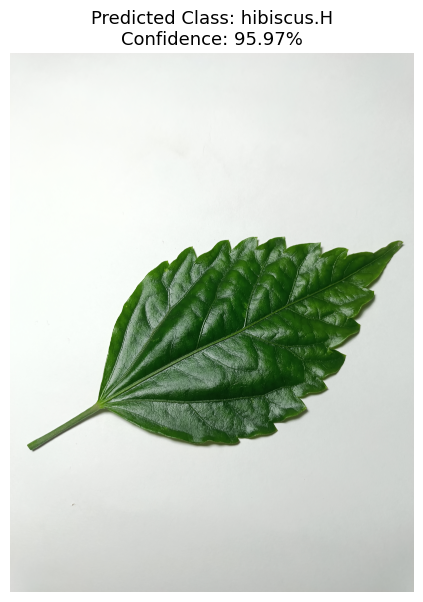

In [11]:
import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tkinter import Tk, filedialog

# ============================================================
# FINAL DEMO
# CNN Prediction + Uncertainty Detection
# ============================================================

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

MODEL_PATH = "plant_disease_recog_model_pwp.keras"
CLASS_NAMES_PATH = "class_names.json"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model not found: {MODEL_PATH}"
    )

if not os.path.exists(CLASS_NAMES_PATH):
    raise FileNotFoundError(
        f"Class names file not found: {CLASS_NAMES_PATH}"
    )


# ------------------------------------------------------------
# 2. Load Model and Class Names
# ------------------------------------------------------------

print("Loading trained CNN model...")

demo_model = tf.keras.models.load_model(
    MODEL_PATH
)

with open(CLASS_NAMES_PATH, "r") as f:
    class_names = json.load(f)

print("✅ CNN model loaded")
print(f"✅ {len(class_names)} classes loaded")


# ------------------------------------------------------------
# 3. Select Image Using Windows File Picker
# ------------------------------------------------------------

print("\nOpening image selector...")

root = Tk()
root.withdraw()
root.attributes("-topmost", True)

image_path = filedialog.askopenfilename(
    title="Select a Plant Image",
    filetypes=[
        (
            "Image Files",
            "*.jpg *.jpeg *.png *.bmp *.webp"
        ),
        (
            "All Files",
            "*.*"
        )
    ]
)

root.destroy()

if not image_path:
    print("❌ No image selected.")
    raise SystemExit

print(f"\nSelected image:\n{image_path}")


# ------------------------------------------------------------
# 4. Load and Prepare Image
# ------------------------------------------------------------

original_img = tf.keras.utils.load_img(
    image_path
)

input_img = original_img.resize(
    (224, 224)
)

img_array = tf.keras.utils.img_to_array(
    input_img
)

img_array = tf.expand_dims(
    img_array,
    axis=0
)


# ------------------------------------------------------------
# 5. Multiple Stochastic Predictions
# ------------------------------------------------------------

NUM_PREDICTIONS = 10

all_predictions = []

for _ in range(NUM_PREDICTIONS):

    # training=True keeps Dropout active
    prediction = demo_model(
        img_array,
        training=True
    ).numpy()[0]

    all_predictions.append(
        prediction
    )

all_predictions = np.array(
    all_predictions
)


# ------------------------------------------------------------
# 6. Calculate Mean Prediction
# ------------------------------------------------------------

mean_prediction = np.mean(
    all_predictions,
    axis=0
)

predicted_index = np.argmax(
    mean_prediction
)

predicted_class = class_names[
    predicted_index
]

mean_confidence = (
    mean_prediction[predicted_index] * 100
)


# ------------------------------------------------------------
# 7. Measure Prediction Stability
# ------------------------------------------------------------

predicted_classes = np.argmax(
    all_predictions,
    axis=1
)

stability = np.mean(
    predicted_classes == predicted_index
) * 100


# ------------------------------------------------------------
# 8. Calculate Prediction Uncertainty
# ------------------------------------------------------------

prediction_std = np.std(
    all_predictions[:, predicted_index]
)

uncertainty = prediction_std * 100


# ------------------------------------------------------------
# 9. Decision Thresholds
# ------------------------------------------------------------

MIN_CONFIDENCE = 70.0
MIN_STABILITY = 70.0
MAX_UNCERTAINTY = 15.0


# ============================================================
# 10. Final Decision
# ============================================================

is_reliable = (
    mean_confidence >= MIN_CONFIDENCE
    and
    stability >= MIN_STABILITY
    and
    uncertainty <= MAX_UNCERTAINTY
)


if is_reliable:

    # --------------------------------------------------------
    # SUPPORTED / RELIABLE PREDICTION
    # --------------------------------------------------------

    print("\n==========================================")
    print("🌿 PLANT DISEASE PREDICTION")
    print("==========================================")
    print(
        f"Predicted Class : {predicted_class}"
    )
    print(
        f"Confidence      : {mean_confidence:.2f}%"
    )
    print(
        f"Stability       : {stability:.2f}%"
    )
    print(
        f"Uncertainty     : {uncertainty:.2f}%"
    )
    print("Status          : Reliable prediction")
    print("==========================================")


    plt.figure(figsize=(7, 7))
    plt.imshow(original_img)
    plt.axis("off")
    plt.title(
        f"Predicted Class: {predicted_class}\n"
        f"Confidence: {mean_confidence:.2f}%",
        fontsize=13
    )
    plt.show()


else:

    # --------------------------------------------------------
    # UNCERTAIN / UNSUPPORTED INPUT
    # --------------------------------------------------------

    print("\n==========================================")
    print("⚠️ UNCERTAIN / UNSUPPORTED INPUT")
    print("==========================================")
    print(
        "The model is not sufficiently confident"
    )
    print(
        "or consistent about this image."
    )
    print("\nPrediction rejected.")
    print(
        f"Highest predicted class : {predicted_class}"
    )
    print(
        f"Confidence              : "
        f"{mean_confidence:.2f}%"
    )
    print(
        f"Prediction stability    : "
        f"{stability:.2f}%"
    )
    print(
        f"Prediction uncertainty  : "
        f"{uncertainty:.2f}%"
    )
    print("==========================================")


    plt.figure(figsize=(7, 7))
    plt.imshow(original_img)
    plt.axis("off")
    plt.title(
        "⚠️ Uncertain / Unsupported Input",
        fontsize=14
    )
    plt.show()